In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import re

AttributeError: module 'pandas' has no attribute 'Series'

In [ ]:
# Path to MLflow runs folder
import os
MLRUNS_PATH = "/home/28s_mur@lab.graphicon.ru/flow_attack/mlruns/914879025403898454"

# List of specific runs to analyze
NEG_FLOW_RUN_IDS = {"666631270ee649f3a839a103fe4ad84a", "b1fb00728c1c45038b3f387f90335e29",
                    "6d4b028bb76743f08f7647dcea5e902b", "82a687b699a64014ae03ddfe67485e25", "b72bf5dac62e4f56b39069c2c0713e36", "663b2e0affec4567b586a0c074657d62", "2535ff1ca49b4643a524f140b28a5348", "8358097738784107a46e117b4a693571", "3cd9ab1f955640228c0f91ff13e8b504", "343bc5235dd94e1eb9fe9fdf0d4885ff", "5e2a64b70a5b4d32a4b3f6671c7c4f6e", "67d398091fc442a1a60bfa9184a4b6cd", "2c00b5b0acd446d8b487bf3911b6a91a", "954a41397a524020af6560dcb2cca958", "d8eebaaf7f4342c3b9dfab5c27c11b37", "43bce625fa0942aba6d4446f9f212d81"}  # Replace with actual run IDs


def load_mlflow_data(mlruns_path, selected_run_ids=None):
    runs_data = []
    metric_columns = set()  # To track all unique metric names
    param_columns = set()   # To track all unique parameter names
    runs = []  # To store the rows of data

    for root, _, files in os.walk(mlruns_path):
        if "meta.yaml" in files and "metrics" in os.listdir(root):
            run_id = os.path.basename(root)
            if selected_run_ids and run_id not in selected_run_ids:
                continue  # Skip runs not in the selected list

            metrics = {}
            params = {}

            # Load parameters
            params_path = os.path.join(root, "params")
            if os.path.exists(params_path):
                for param_file in os.listdir(params_path):
                    with open(os.path.join(params_path, param_file), "r") as f:
                        params[param_file] = f.read().strip()
                        # Track the parameter name
                        param_columns.add(param_file)

            # Load metrics
            metrics_path = os.path.join(root, "metrics")
            if os.path.exists(metrics_path):
                for metric_file in os.listdir(metrics_path):
                    with open(os.path.join(metrics_path, metric_file), "r") as f:
                        values = [line.split() for line in f.readlines()]
                        # Keep the latest metric value
                        # Last value in the list is the latest
                        try:
                            latest_value = float(values[-1][1])
                        except:
                            print(run_id)
                        metrics[metric_file] = latest_value
                        # Track the metric name
                        metric_columns.add(metric_file)

            # Create a row that includes run_id, parameters, and latest metrics
            row = {"run_id": run_id}
            for param_name in param_columns:
                # Use None if the parameter is missing
                row[param_name] = params.get(param_name, None)
            for metric_name in metric_columns:
                # Use None if the metric is missing
                row[metric_name] = metrics.get(metric_name, None)

            runs.append(row)

    # Ensure all rows have consistent columns for both metrics and parameters
    for run in runs:
        # Ensure every row has the same columns for parameters and metrics
        for param_name in param_columns:
            if param_name not in run:
                run[param_name] = None  # Add None for missing parameters
        for metric_name in metric_columns:
            if metric_name not in run:
                run[metric_name] = None  # Add None for missing metrics
    
    return runs



# Load only selected runs
data = pd.DataFrame(load_mlflow_data(MLRUNS_PATH, NEG_FLOW_RUN_IDS))
data['epsilon']
# data[data['run_id'] =='d8eebaaf7f4342c3b9dfab5c27c11b37']['mean_aee_target_attack_step_5']

In [ ]:

import matplotlib.pyplot as plt
import pandas as pd
import re
import math


def plot_epsilon_vs_aee(runs_data, metric='mean_aee_target_attack_step_', apgd_eps_to_metrics = {}):
    # Ensure `runs_data` is a DataFrame
    if not isinstance(runs_data, pd.DataFrame):
        raise ValueError("runs_data must be a pandas DataFrame")
    
    if "target" in metric:
        metric_label = "target flow"
    elif "init" in metric:
        metric_label = "initial flow"
    elif "gt" in metric:
        metric_label = "ground truth"
    else:
        metric_label = metric.replace("_", " ")  # Default to metric name
    # Get unique epsilon values and attack types
    epsilon_groups = runs_data.groupby("params.epsilon")

    # Get a sorted list of attack types (ensures consistent order)
    unique_attacks = sorted(runs_data.groupby(
        ["params.attack_type", "params.no_softmax"]).groups.keys())

    # Assign colors to each attack type in the same order
    colors = plt.get_cmap("tab10")
    attack_color_map = {attack: colors(idx % 10)
                        for idx, attack in enumerate(unique_attacks)}

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.flatten()
    # if len(epsilon_groups) == 1:
    #     axes = [axes]  # Ensure axes is always iterable

    fig.suptitle(
        f'Comparison of Mean AEE to {metric_label} on Kitti15 for different alpha (ε=8/255)',
        fontsize=16
    )

    # Mapping epsilon values to fraction format
    eps_map = {0.00392: '1/255', 0.00784: '2/255',
               0.01568: '4/255', 0.03137: '8/255'}

    # Iterate over each epsilon group
    for idx, (epsilon, group) in enumerate(epsilon_groups):
        ax = axes[idx]
        epsilon = float(epsilon)
        eps_frac = eps_map.get(epsilon, str(epsilon))
        ax.set_title(
            f'Epsilon: {eps_frac} vs Mean AEE to {metric_label}', fontsize=14)
        ax.set_xlabel('Number of Iterations in attack', fontsize=12)
        ax.set_ylabel(
            f'Mean AEE between {metric_label} and attacked flow', fontsize=12)

        # Plot each attack type in a predefined order
        for attack_key in unique_attacks:
            print(attack_key)
            attack_type, no_softmax = attack_key
            legend_label = f"Attack: {attack_type} {'(No Softmax)' if no_softmax == 'True' else ''}"

            # Filter rows for the current attack type
            attack_rows = group[(group["attack_type"] == attack_type) & (
                group["no_softmax"] == no_softmax)]
            if attack_rows.empty:
                continue  # Skip if no matching rows
            if attack_type == 'APGD':
                step_number, metric_value = apgd_eps_to_metrics[str(epsilon)]
                
                ax.plot(step_number, metric_value, marker="o",
                        label=legend_label, color=attack_color_map[attack_key])
            else:
                values = {}
                for _, row in attack_rows.iterrows():
                    for column, value in row.items():
                        if column.startswith('metrics.'+metric):
                            step_number = re.search(r'(\d+)$', column)
                            if step_number:
                                step_number = int(step_number.group(1))
                                values[step_number] = value

                    # Sort the values by step number
                    sorted_items = sorted(values.items())
                    sorted_steps = [key for key, value in sorted_items]
                    sorted_metrics = [value for key, value in sorted_items]

                    # Plot using consistent colors and order
                    ax.plot(sorted_steps, sorted_metrics, marker="o",
                            label=legend_label, color=attack_color_map[attack_key])

        # Ensure consistent legend order
        handles, labels = ax.get_legend_handles_labels()
        legend_order = [
            f"Attack: {atk} {'(No Softmax)' if ns == 'True' else ''}" for atk, ns in unique_attacks]
        sorted_legend = sorted(zip(labels, handles),
                               key=lambda x: legend_order.index(x[0]))
        ax.legend([h for l, h in sorted_legend], [
                  l for l, h in sorted_legend], loc='best')

        ax.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
# Example Usage:
# Assuming `runs_data` is already loaded with the data from `load_mlflow_data`
plot_epsilon_vs_aee(data, metric='mean_aee_init_attack_step_')

In [ ]:
ZERO_FLOW_RUN_IDS = {'453f6881f37647c1886e2bb292831ecf',
                     '489cb7051fa04e5c824a17f2d853798e', 'e2eca6bf1c204bdf925786dcf260fb20', '61564a1e2b6f472c930501a29aaf2e59', '26a791256666439e9fdee5b2b4c63637', 'fc76dca0216047c983cf32cc0b752879', '365080b4147b49c78050ca03e2ad74b2', '8c22e922558e4898a46cf7d6fbd21f4c', '61ab98ff3e0b4588949cea3520b2eb2c', 'e9e5f4932ff042cbb6144918b4eed711', 'e0df216f3a2a4359bae36436678d4e19', 'ec158121700644a9834201ce31e79dec', '28258365bfad400f9ada5b1d7fce19c0', '5c2dc8bfa36747759c22de875f091b10', '65229fc8582946dcac32ebf4c82e93b8', 'ba98e8dcd7cb4e4b8dde36d8ff0ca637'}

In [ ]:
APGD_RUN_IDS = {"430f24b2ee2f49eea3661996ddb21e6c", "3b5c0e4b8f424a578d260281ffb01b6a","636d1fad49544a97a0e203fc99ef1444","c770f9bb65eb4b729393c5958bfe6c0a"}

In [ ]:
NEW_APGD_RUN_IDS = {"a9b53409bbb24f4fbda24ed3c027cb64", "3799c743bb5c474485a45e932063bd0f","5278e0e35ef94d8184e9799f0f26f013","a92b637c87384769b9cd5600c1990ecb","5a7c6a7caa3547c488f4c3e28a3b8949","7dad2411d345482c815c5f0e3ffb3e01","1d56b77a5bff4647b55e6bbfc96ce726","c736d473c99c407a92386f7897ab9c34","71416297d6df4a1f90571abfcc630350","ec16dfe33bd443b0a009c1a5e0cf479e","41ec9051544549eba9992ca1a908770c","f91b2bba65a4447c837661dbd9d204fa","6e1cb02cc72f4ef683b855fed386b2b8","9c5701ccc49d4626a6fb3a1cce2e6d73","6f24c7ae63e546d0bbea4ac668f90ac8","9874ab4f57c44028a110fe7d4b2b02c0","46830a877c4a4b0da37d3efb3d23fc14","c42dd2a3499f4562988fb45549cf5e3d","bcf4da5b39814cf9acfa55a4751d50ea","948e2e77a667471290b91b2b1bd67173","7216e150f24a44d38cc981b50ae93643","3d50579edb3b4b1a8105f977f043d43c","6c7542fe377b46778d7bcd50d07d868d","d3a6248bd5db4c3bbbb87066aff25ba1","1908085a02a34f208ddc8bff5674cabc","b48e9baae5694bba80c3dec12af0504d","67a0f47abf064f5ba2f989f4b4a8fd56","e9ac3c5233b14741951c1dbeae43fbe8","48b67696454c4b4b9ed26e2ba2d50dfd","4800aaf72b7e4fcc8bd159af11389070","99a9b21438234768b009545cf0e37aca","cc406dceca3e4be09c5ca50c24c0a4e5","daae26d28d18465fb0d249ee08dc5776","f2576419d5e24b7292ffb98d785680d6","4556372f3ed44f51853b04d6997857df","67f7ec47cfd94f49a8c48415b862f6cb"}

In [ ]:
MIFGSM_COSPGD = {"66bbd1be1f4940db9eff86b9bcc6c448","35ff802df10740d0a829d9d9ca7794cc","bd1d17565c304a5798194fcd2aa276e9","e3a53124ef6c4f4f9bcdf052cd5ea846"}

In [ ]:
APGD_SMALL_RUN_IDS = {"d1ee78568c58463cb39372348b7843df"}
apgd = pd.DataFrame(load_mlflow_data(MLRUNS_PATH, APGD_SMALL_RUN_IDS))
apgd['attack_type'] = 'APGD (5 steps)'
apgd['epsilon'] = '0.03137'

In [ ]:
zero_flow = pd.DataFrame(load_mlflow_data(MLRUNS_PATH, ZERO_FLOW_RUN_IDS|APGD_RUN_IDS|MIFGSM_COSPGD))
zero_flow[zero_flow['epsilon'] == '0.03137']

In [ ]:
plot_epsilon_vs_aee(zero_flow, metric="mean_aee_init_attack_step_", apgd_eps_to_metrics=apgd_eps_to_metrics)

In [ ]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re


def plot_epsilon_vs_aee_scaled_loss(runs_data, metric='mean_aee_target_attack_step_', max_step=40):
    # Ensure `runs_data` is a DataFrame
    if not isinstance(runs_data, pd.DataFrame):
        raise ValueError("runs_data must be a pandas DataFrame")

    # Get unique epsilon values and attack types
    epsilon_groups = runs_data.groupby("epsilon")

    # Get a sorted list of attack types (ensures consistent order)
    unique_attacks = sorted(runs_data.groupby(
        ["attack_type", "target_layer"]).groups.keys())

    # Assign colors to each attack type in the same order
    colors = plt.get_cmap("tab10")
    attack_color_map = {attack: colors(idx % 10)
                        for idx, attack in enumerate(unique_attacks)}

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.flatten()
    if len(epsilon_groups) == 1:
        axes = [axes]  # Ensure axes is always iterable

    fig.suptitle(
        'Comparison of different scaled losses on Kitti15 for different epsilon', fontsize=16)

    # Mapping epsilon values to fraction format
    eps_map = {0.00392: '1/255', 0.00784: '2/255',
               0.01568: '4/255', 0.03137: '8/255'}

    # Iterate over each epsilon group
    for idx, (epsilon, group) in enumerate(epsilon_groups):
        ax = axes[idx]
        epsilon = float(epsilon)
        eps_frac = eps_map.get(epsilon, str(epsilon))

        ax.set_title(f'Epsilon: {eps_frac} vs Mean AEE to init', fontsize=14)
        ax.set_xlabel('Number of Iterations in attack', fontsize=12)
        ax.set_ylabel('Mean AEE between init and attacked flow', fontsize=12)

        # Plot each attack type in a predefined order
        for attack_key in unique_attacks:
            attack_type, target_layer = attack_key
            legend_label = f"Attack: {attack_type} {target_layer if not pd.isna(target_layer) else ''}"

            # Filter rows for the current attack type
            attack_rows = group[
                (group["attack_type"] == attack_type) & 
                (
                    (group["target_layer"] == target_layer) | 
                    (pd.isna(group["target_layer"]) & pd.isna(target_layer))
                )
            ]
            if attack_rows.empty:
                continue  # Skip if no matching rows
            if attack_type == 'APGD':
                base_metric = metric.replace('_step_', '')
                for _, row in attack_rows.iterrows():
                    for column, value in row.items():
                        if column == base_metric:
                            step_number = int(row['steps'])
                            metric_value = value
                ax.plot(step_number, metric_value, marker="o",
                        label=legend_label, color=attack_color_map[attack_key])
            else:
                values = {}
                for _, row in attack_rows.iterrows():
                    for column, value in row.items():
                        if column.startswith(metric):
                            step_number = re.search(r'(\d+)$', column)
                            if step_number:
                                step_number = int(step_number.group(1))
                                if step_number <= max_step:
                                    values[step_number] = value

                # Sort the values by step number
                sorted_items = sorted(values.items())
                sorted_steps = [key for key, value in sorted_items]
                sorted_metrics = [value for key, value in sorted_items]

                # Plot using consistent colors and order
                ax.plot(sorted_steps, sorted_metrics, marker="o",
                        label=legend_label, color=attack_color_map[attack_key])

        # Ensure consistent legend order
        handles, labels = ax.get_legend_handles_labels()
        legend_order = [
            f"Attack: {atk} {target_layer if not pd.isna(target_layer) else ''}" for atk, target_layer in unique_attacks]
        sorted_legend = sorted(zip(labels, handles),
                               key=lambda x: legend_order.index(x[0]))
        ax.legend([h for l, h in sorted_legend], [
                  l for l, h in sorted_legend], loc='best')

        ax.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
COSPGD_RUN_IDS = {'ec158121700644a9834201ce31e79dec', 'e2eca6bf1c204bdf925786dcf260fb20', '65229fc8582946dcac32ebf4c82e93b8', '453f6881f37647c1886e2bb292831ecf'}

In [ ]:
HIGH_FREQ_RUN_IDS = {'950484a899d647bcbc48930d12ebda33', '5c74451d4bca4200b2f93c03ff15d337', '8db7b02cbee44e5da2328348ad3e45f5',	'fd198de526c4487489f4c9e8731fc33d'}
HighFreq_df = pd.DataFrame(load_mlflow_data(MLRUNS_PATH, HIGH_FREQ_RUN_IDS))
HighFreq_df['attack_type'] = 'High frequency'

In [ ]:
SOBEL_RUN_IDS = {"c0686835bbb54b9081a73db33bb90d8e", "ba2036068b6a451d9ad18680b75ead7d","c45bfbecba464ddab686a5b22c0c2267","508235141bcf46648f6f136935448d7a"}
Sobel_df = pd.DataFrame(load_mlflow_data(MLRUNS_PATH, SOBEL_RUN_IDS))


In [ ]:
GRADCAM_RUN_IDS = {'b5d0631da9134f35b9e8ac9a3ae4eb13',
                   '10600ab2700044cc925b1d1b6f436b44', 'ccccaec6a30b420196903e7a164ce790', '71f7c1d03d964787ae3b6824c3e9bba7', '15f0bb9b035c4849a015003e51cceb26', '7ce0fd142657458cbd9a221a9dd35f39', '7e998f7dd4784a63901d0c7127f13da4', 'b6545bc12c7246dbb734e9576b645067', '6ff2223d307a4f1c8040180ff48691e1', '7313a9acc55e4de19fac50da44f96372', 'c273604ca80145bba520e88908dad7b1', '60be9a2064f2449c9dcef1bc12cf68e6'}
GradCAM_df = pd.DataFrame(load_mlflow_data(MLRUNS_PATH, GRADCAM_RUN_IDS|COSPGD_RUN_IDS))
GradCAM_df = pd.concat([GradCAM_df, HighFreq_df, Sobel_df])


In [ ]:
plot_epsilon_vs_aee_scaled_loss(GradCAM_df, 'mean_aee_init_attack_step_', max_step=20)

In [ ]:
SOBEL_RUN_IDS = {'a3b161c0cd574fddb2fd0149672a18ec',
                 '36a94a5f2d724ee2a6c7171235e70aff'}
HighFreq_df = pd.DataFrame(load_mlflow_data(MLRUNS_PATH, SOBEL_RUN_IDS))

In [7]:
new_attacks = ["8aaf34f500ae43f395067ca22a925798", "d386512da5ca4ded85132d96d05a37ee","2d446d01b65b4f3e941ec02b8ee612bd","496c614f3a5947758a49a130cc291bcb","76d5d047bb794283908183b8d565a172","86c3d0c1e36240a3b95a0d862cbb216e","80118d4ad8074217855836c3f734f60d","784085837d2848f4a2919610a998af72","a4facc29ba544cf7b95a578810133b30","75924ae506e046dabdc32d939bf249da","fa4b35bc1c8145fd821e37e5de4431ef","5651073c5f054947b623405997d54290","5f3d96d214e34f68bf84f699afec5780","ab5f4b43a6d74442a7233dda3879e9a4","f550306f13d84487877fd84681415f26","172ee47f74ad47e9ba262289813adcd8","6fe67e71263a4276949161ff010b1c87","d644253a8f184346a4c98e663477e9b0","6f8302b3648f44e38fde85ccfe32c172","94ecd0437e3c41f0bb9f1a8882f04a4e"]
old_mifgsm = ["bd47324e647a4790bbc949b06947b2f2","dec0eb80cc0e4b85b1141ac5ecb88a9c","58d7a0c23a8a473a9f59e9c6a1fa762d","fbae4878498e4b35a717df90c1248a8c"]
ids_str = ", ".join(f"'{run}'" for run in new_attacks+ old_mifgsm)
# Формируем финальный запрос
filter_string = f"attributes.run_id IN ({ids_str})"

In [3]:
import mlflow
import pandas as pd
mlflow.set_tracking_uri('../mlruns')
experiment_id = "914879025403898454"

In [8]:
runs = mlflow.search_runs(experiment_ids=[experiment_id], filter_string=filter_string)



In [ ]:
runs[runs['params.attack_type'] == 'MIFGSM']['run_id'].to_list()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np


def plot_alpha_vs_aee(runs_data, metric='mean_aee_target_attack_step_'):
    if not isinstance(runs_data, pd.DataFrame):
        raise ValueError("runs_data must be a pandas DataFrame")

    # Determine the keyword in the metric name for title adjustment
    if "target" in metric:
        metric_label = "target flow"
    elif "init" in metric:
        metric_label = "initial flow"
    elif "gt" in metric:
        metric_label = "ground truth"
    else:
        metric_label = metric.replace("_", " ")  # Default to metric name

    # Copy and preprocess data
    runs_data = runs_data.copy()
    runs_data["params.alpha"] = runs_data["params.alpha"].astype(float)
    runs_data["params.no_softmax"] = runs_data["params.no_softmax"].astype(str)

    # Ensure categorical values for consistent grouping
    runs_data["params.target_layer"] = runs_data["params.target_layer"].astype(
        str)
    runs_data["params.use_map_scaling"] = runs_data["params.use_map_scaling"].astype(
        bool)
    runs_data["params.scaling_type"] = runs_data["params.scaling_type"].astype(str)
    # Group by attack type
    epsilon_groups = runs_data.groupby("params.epsilon")

    # Get unique (target_layer, use_map_scaling) combinations
    unique_target_layers = sorted(runs_data["params.loss"].unique())

    # Assign colors based on unique target layers
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_target_layers)))
    color_map = {layer: colors[idx]
                 for idx, layer in enumerate(unique_target_layers)}

    # Define marker styles for map scaling
    # Square for map scaling, Circle otherwise
    marker_styles = {True: "s", False: "o"}

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.flatten()

    fig.suptitle(
        f'Comparison of Mean AEE to {metric_label} on Sintel for different epsilon',
        fontsize=16
    )

    eps_map = {0.00392: '1/255', 0.00784: '2/255',
               0.01568: '4/255', 0.03137: '8/255'}

    for idx, (epsilon, group) in enumerate(epsilon_groups):
        ax = axes[idx]
        epsilon = float(epsilon)
        eps_frac = eps_map.get(epsilon, str(epsilon))
        ax.set_title(
            f'Epsilon: {eps_frac} vs Mean AEE to {metric_label}', fontsize=14)
        ax.set_xlabel('Number of Iterations in attack', fontsize=12)
        ax.set_ylabel(
            f'Mean AEE between {metric_label} and attacked flow', fontsize=12)

        for _, row in group.iterrows():
            target_layer = row["params.scaling_type"]
            use_map_scaling = row["params.use_map_scaling"]

            # Select color based on target layer
            color = color_map[target_layer]

            # Select marker based on use_map_scaling
            marker = marker_styles[use_map_scaling]

            # Extract attack steps and metric values
            values = {}
            for column, value in row.items():
                if column.startswith('metrics.' + metric):
                    step_number = re.search(r'(\d+)$', column)
                    if step_number:
                        step_number = int(step_number.group(1))
                        values[step_number] = value

            # Sort values by step number
            sorted_items = sorted(values.items())
            sorted_steps = [key for key, _ in sorted_items]
            sorted_metrics = [value for _, value in sorted_items]

            legend_label = f"Attack: {row['params.attack_type']}, scaling: {target_layer}"
            ax.plot(
                sorted_steps, sorted_metrics, linestyle="-", marker=marker,
                label=legend_label, color=color, markersize=8
            )

        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

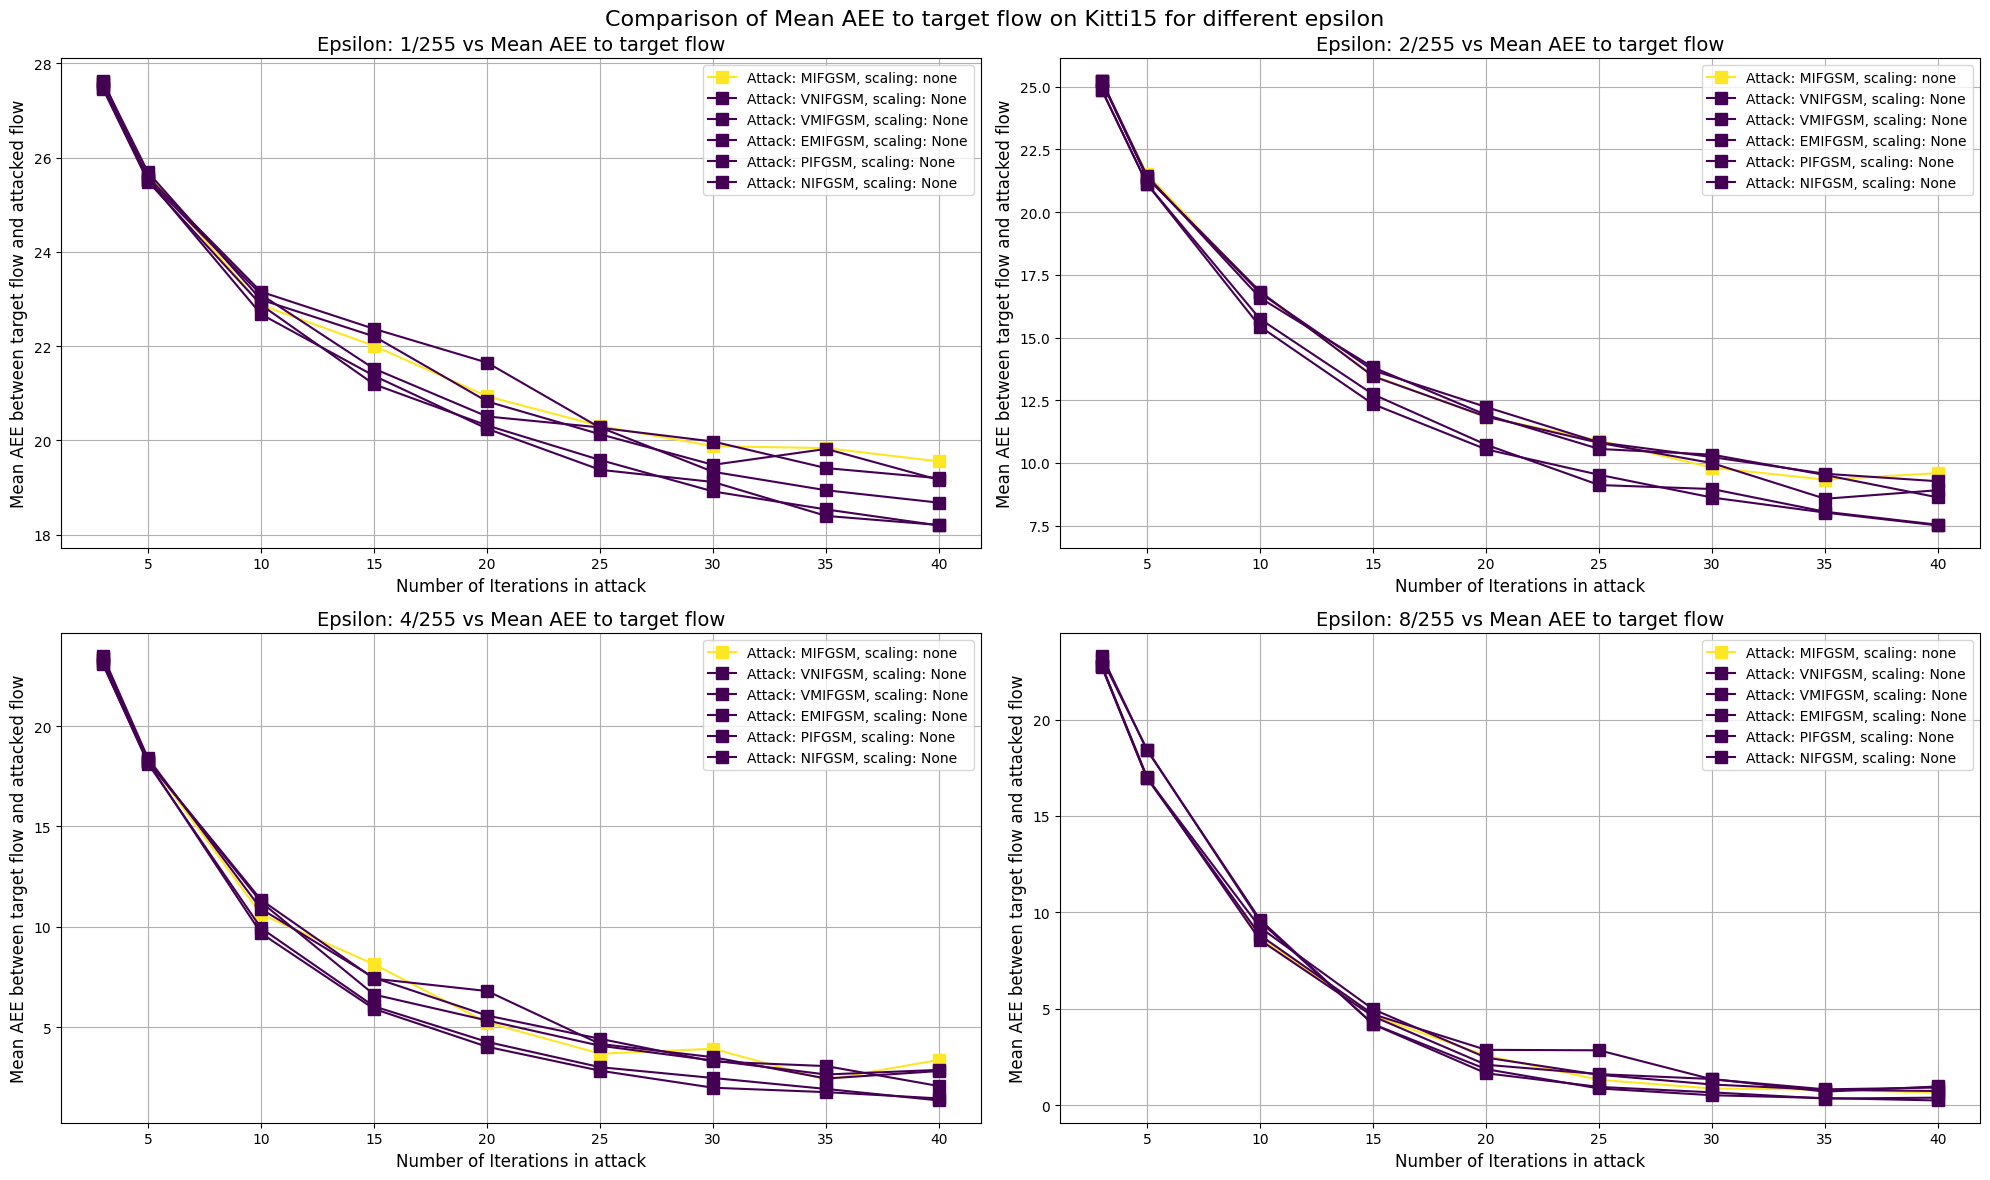

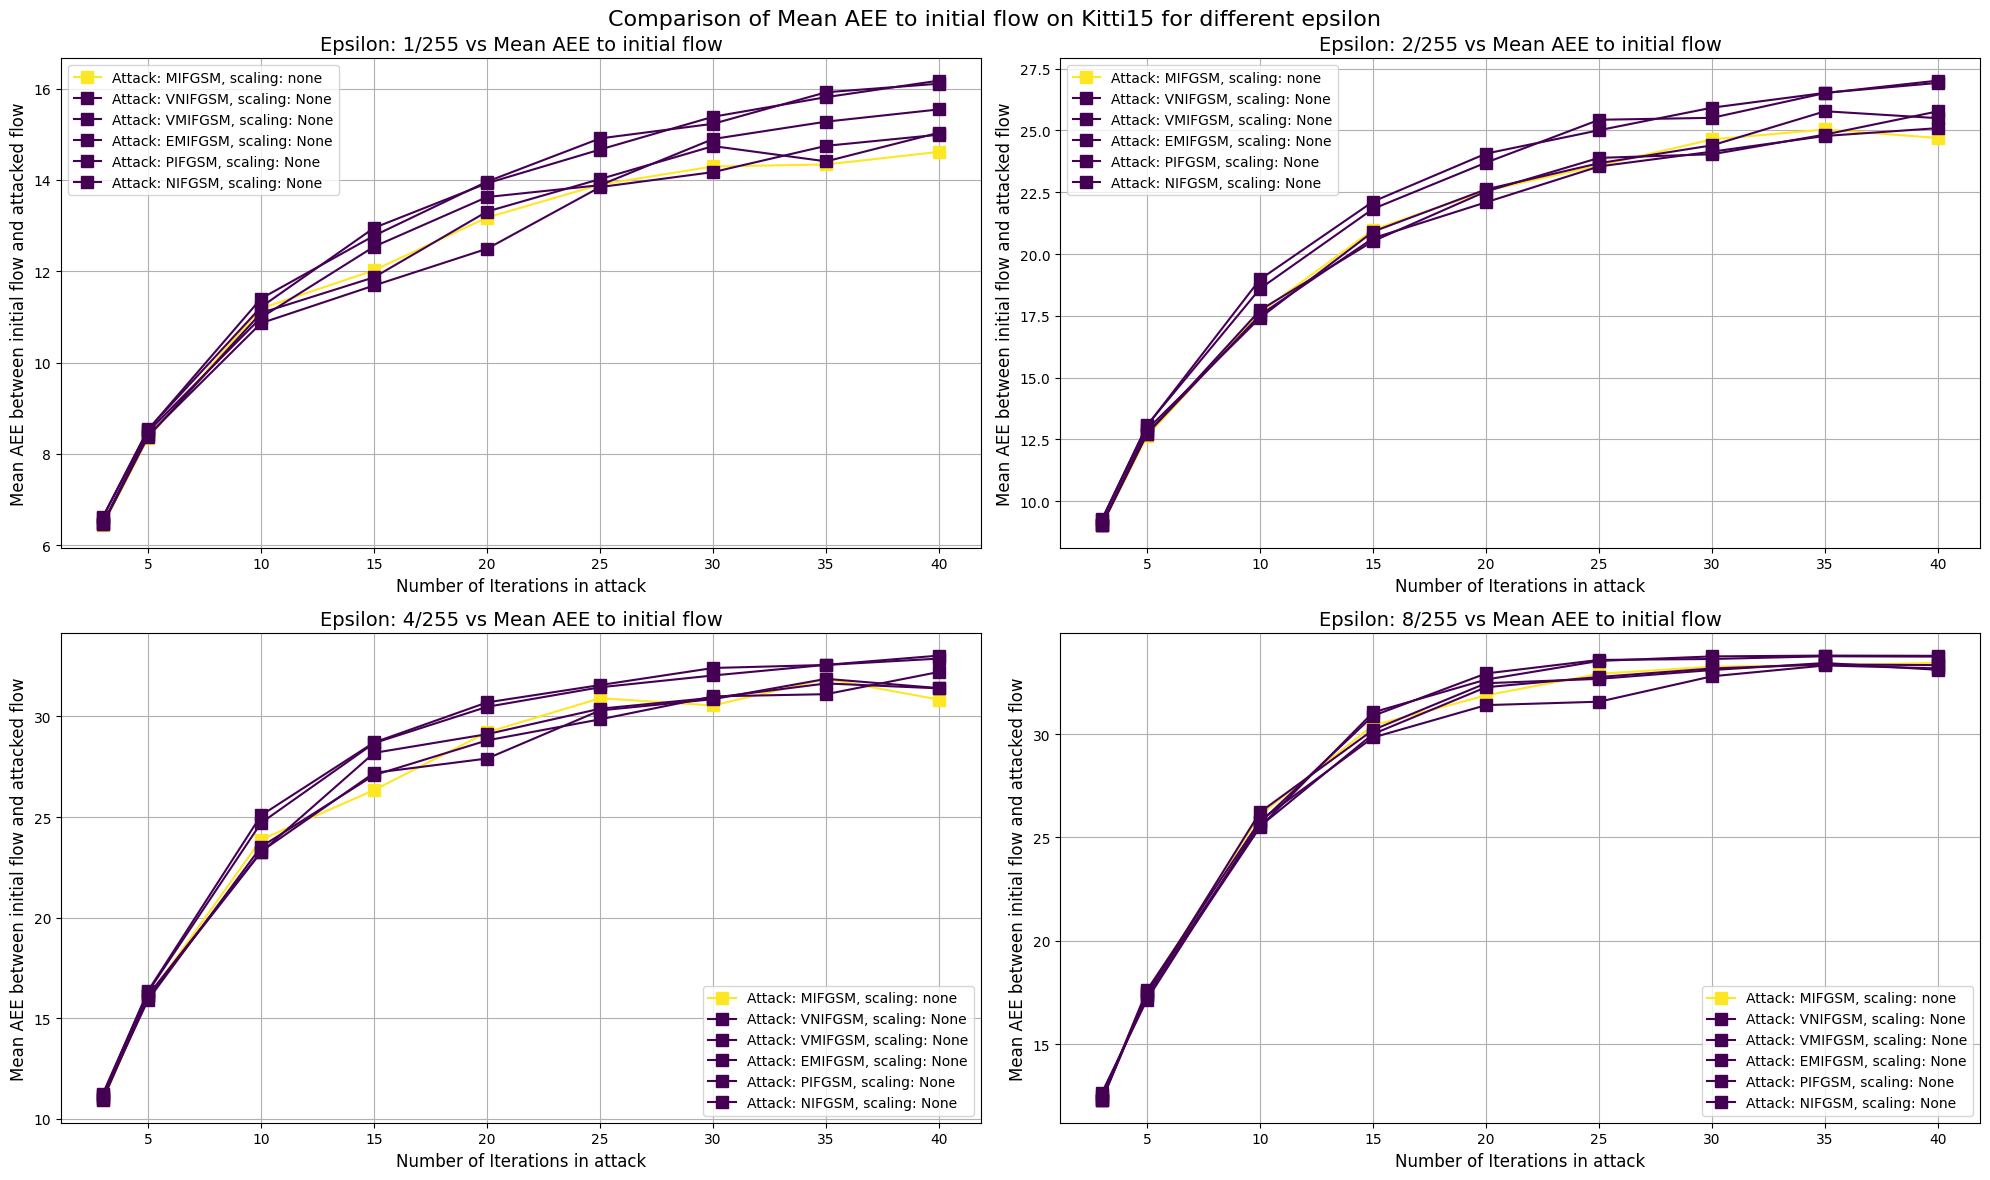

In [7]:
plot_alpha_vs_aee(runs)
plot_alpha_vs_aee(runs, 'mean_aee_init_attack_step_')

In [4]:
mifgsm_runs = ["ee74a4e26d724873becaa33a52bc0dc0", "d66080b5e5ad448193bce9356a9518c3", "825abe65b2d845cfa1d42782805da37e", "0c72b65e19144107879b075d6d0c5984", "05f7fd89c1b644f2b563f7dfaaea8021", "71931bd2fe2b413f8a3511f983933d00", "9b1df723777843f2a0feedacdc9a9ce0", "a67140fe915b43af973177b185cc731f",
               "7d57af727d0641acbd952c1555c90881", "aeadfec94cb54f93a5e460e137c23c51", "8f322291f57d447994c950fb01ccc33c", "78d6d38ea6994ec99bb4e4f9a9397a47", "034c08fcca7747f3b6920e568d75bc41", "6a07187e1dcc4ec7a4c2115c0e726592", "2e2e35943eb84ec4a1c46326a895bc3c", "bfb7d39a21a24a06be5e0b59deeffe34"]
ids_str = ", ".join(f"'{run}'" for run in mifgsm_runs)
# Формируем финальный запрос
filter_string = f"attributes.run_id IN ({ids_str})"
runs = mlflow.search_runs(
    experiment_ids=[experiment_id], filter_string=filter_string)

In [ ]:
runs['start_time_ts'] = pd.to_datetime(runs['start_time'], unit='ms')
runs['end_time_ts'] = pd.to_datetime(runs['end_time'],   unit='ms')


# 2. compute a timedelta column
runs['duration'] = runs['end_time_ts'] - runs['start_time_ts']

# now you have a nice pandas timedelta column:
print(runs[['run_id', 'start_time_ts','end_time_ts','duration']])

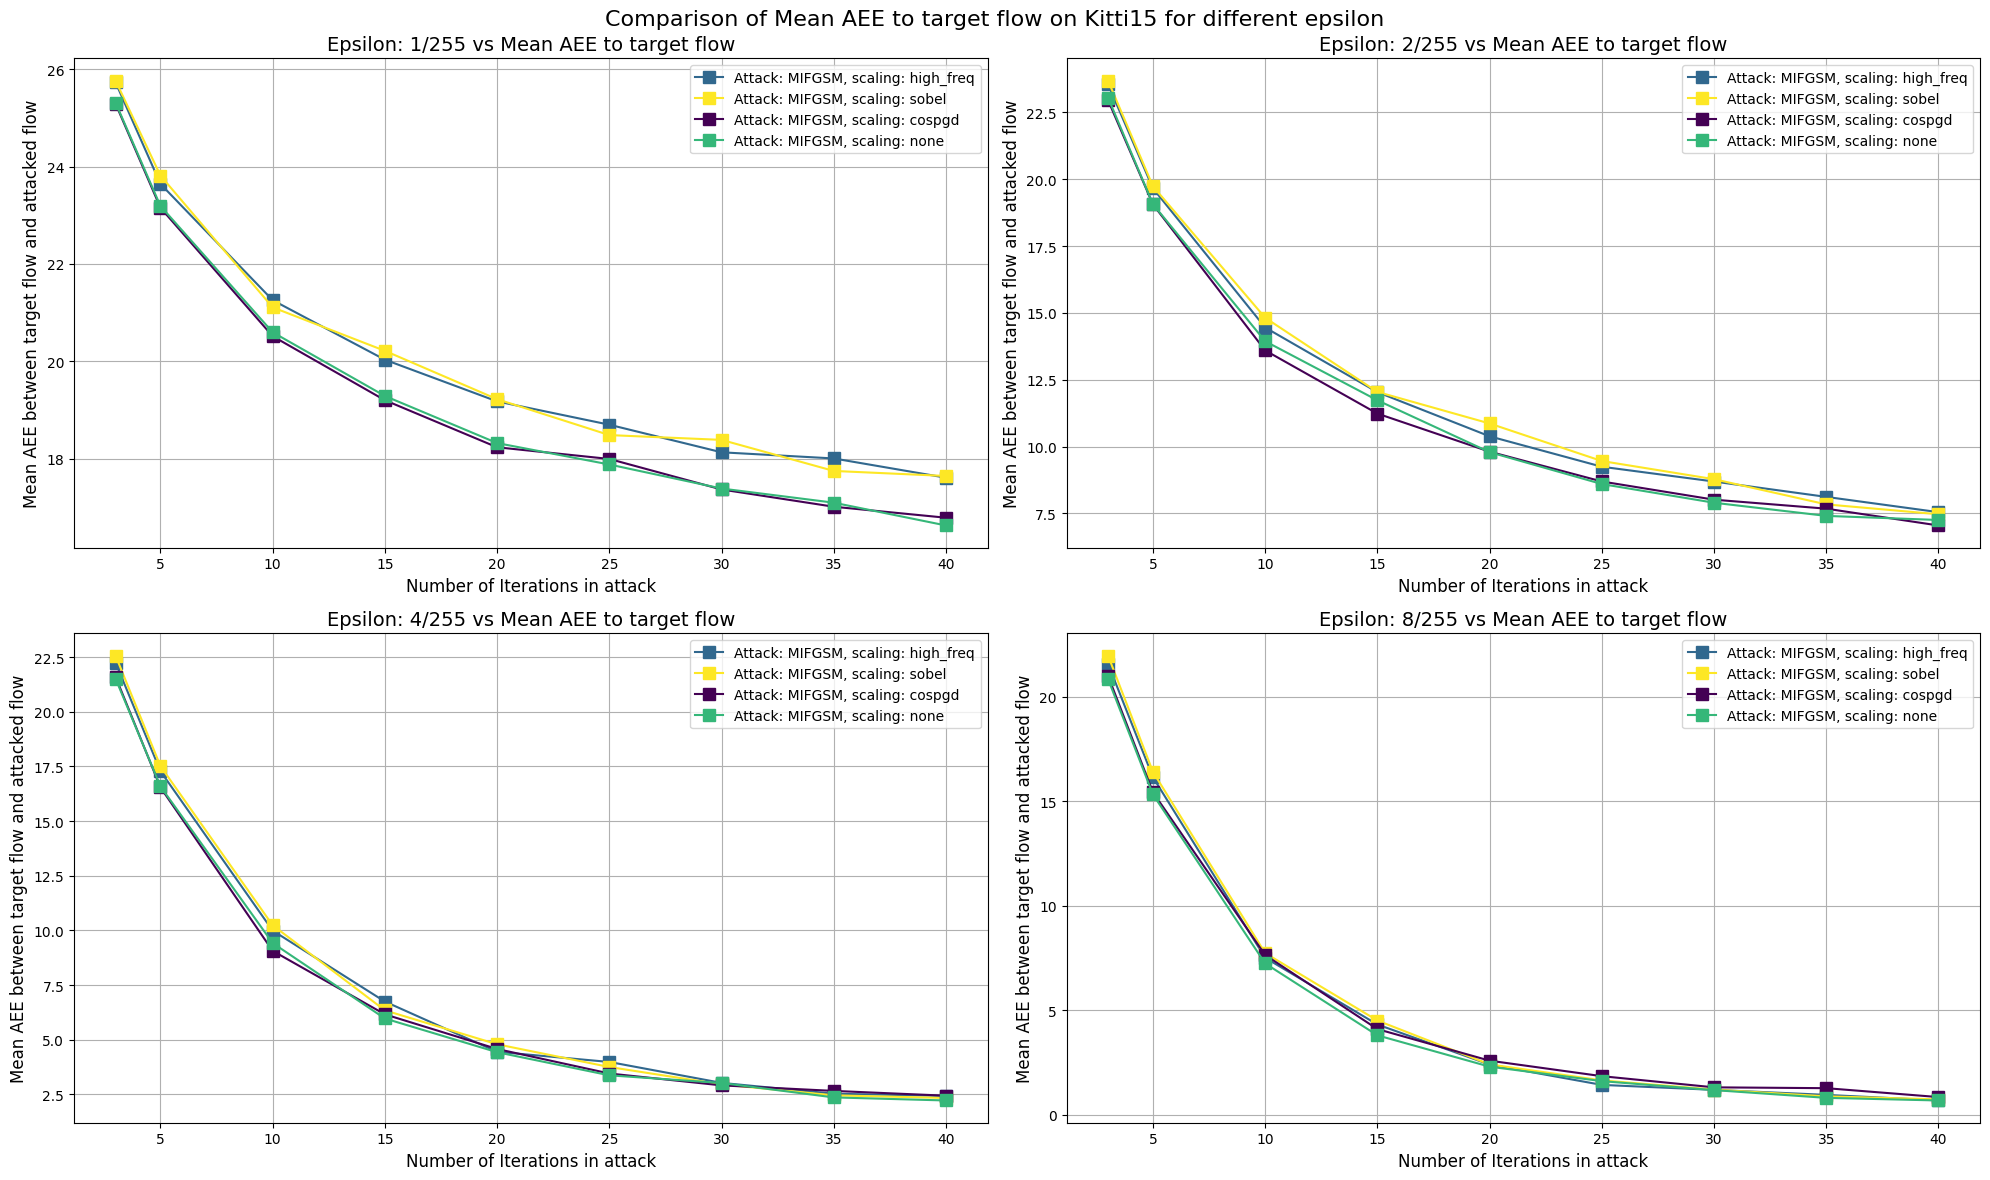

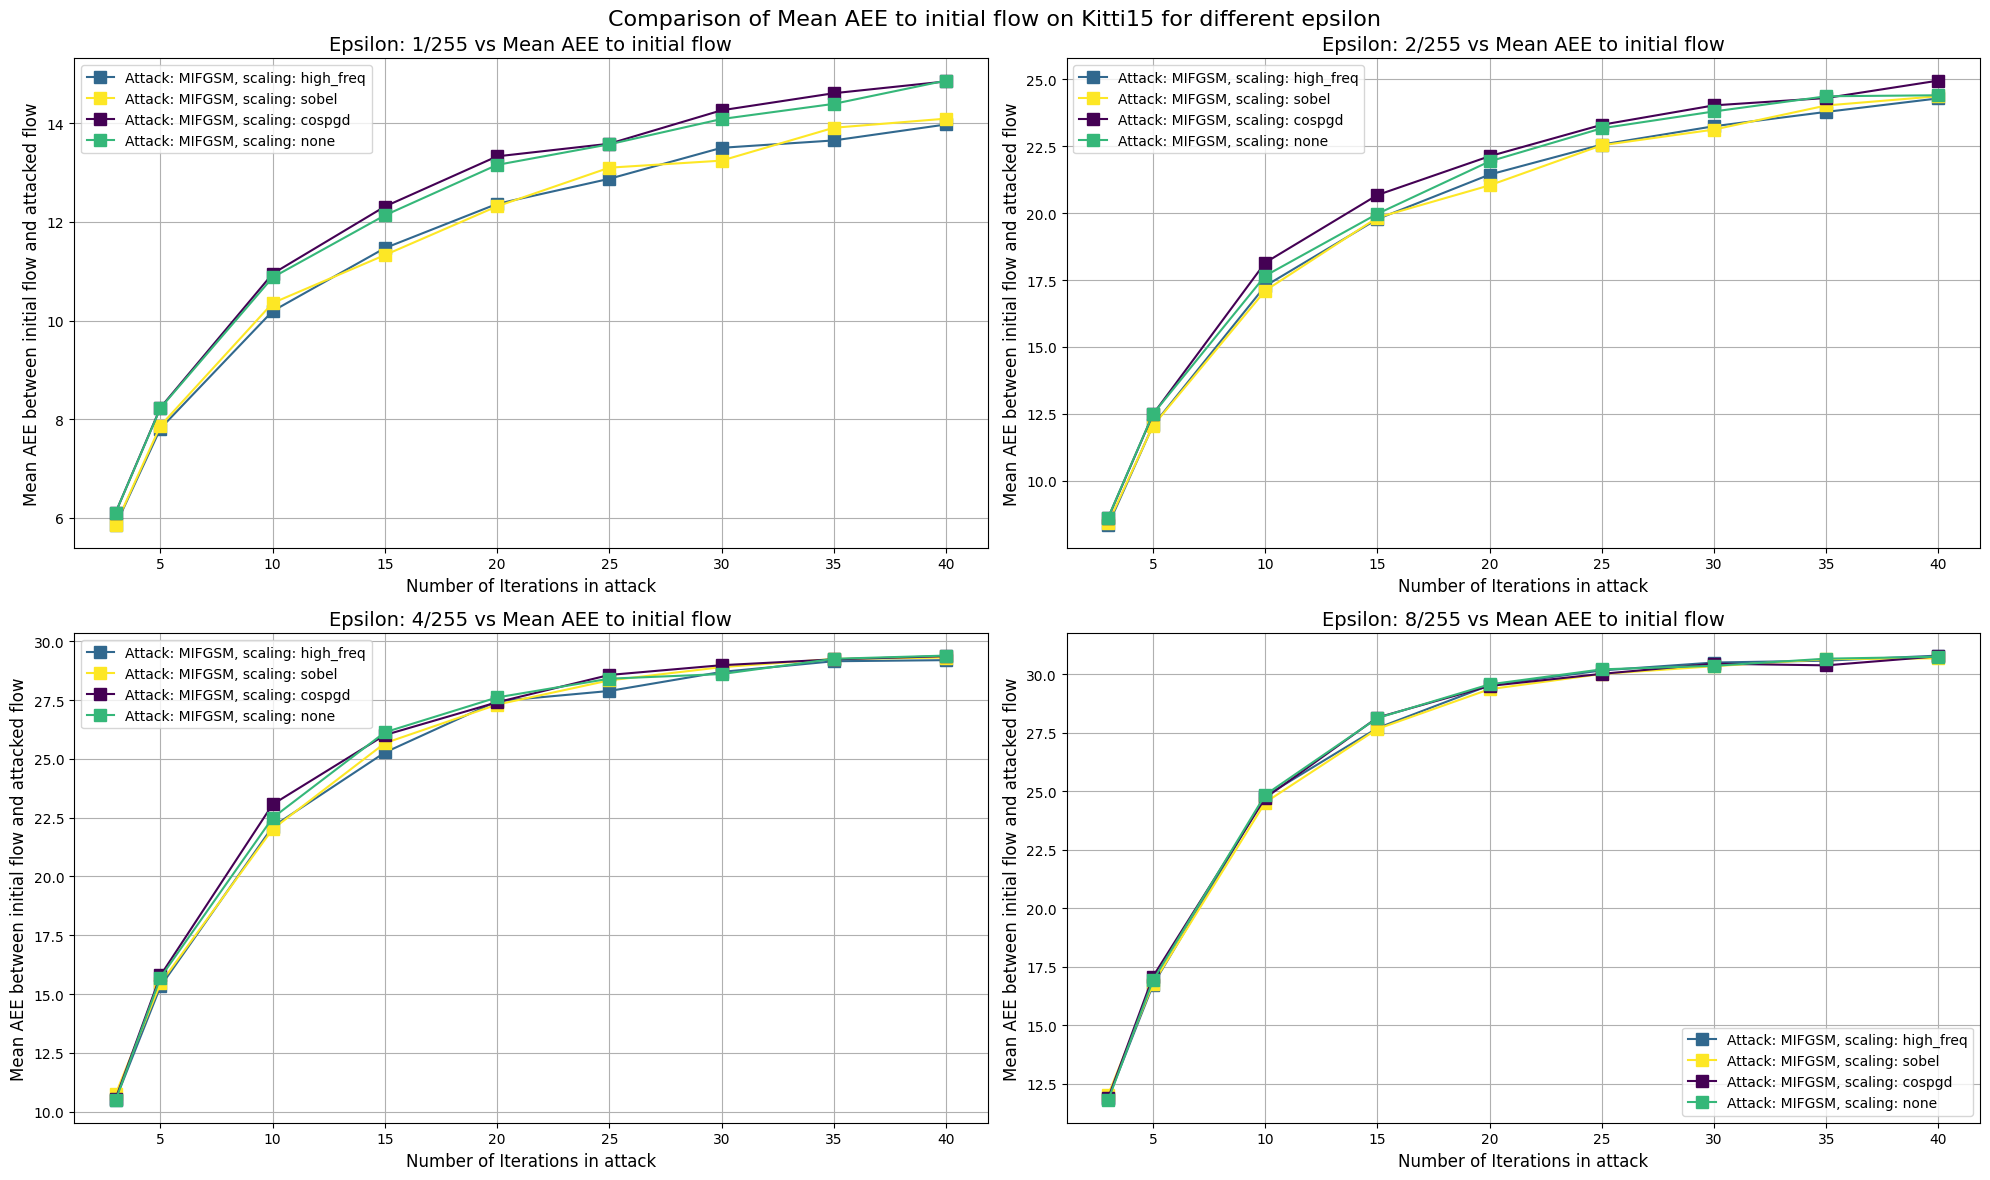

In [7]:
plot_alpha_vs_aee(runs)
plot_alpha_vs_aee(runs, 'mean_aee_init_attack_step_')

In [8]:
mifgsm_runs = ["6aacdcc498094071b713ed37b6458681","2a12cb376f934d5294abaf746fd7c3f8","38eecb7f9f794281b8b206eb0a98aaf7","5a5e4750a7cf46d9972d038f902c04a5","aaf8fce8972e416ea29f490390350a0f","a8cb821931f54a02b0e8e89198508559","f4231d545b984e37967179a21cf105aa","7752b1a9f61f47df8c6579b5fb318a38","fb3fa1dfb96048428c177ca992895865","b95b2ded73f5488db102effce21207c8","284ff7c6930c433988848c4815fabfc6","7a9a469347c4436f9737473245fb60fb","2027f85da47a4f1694cbc4cc3887f6b5","90d0b698699c49deb7d4818a1b492dff","829988a804b049a786788cb6076eb55b","5472ed6d05fb44a09e3abb4486bca700"]
ids_str = ", ".join(f"'{run}'" for run in mifgsm_runs)
# Формируем финальный запрос
filter_string = f"attributes.run_id IN ({ids_str})"
runs = mlflow.search_runs(
    experiment_ids=[experiment_id], filter_string=filter_string)

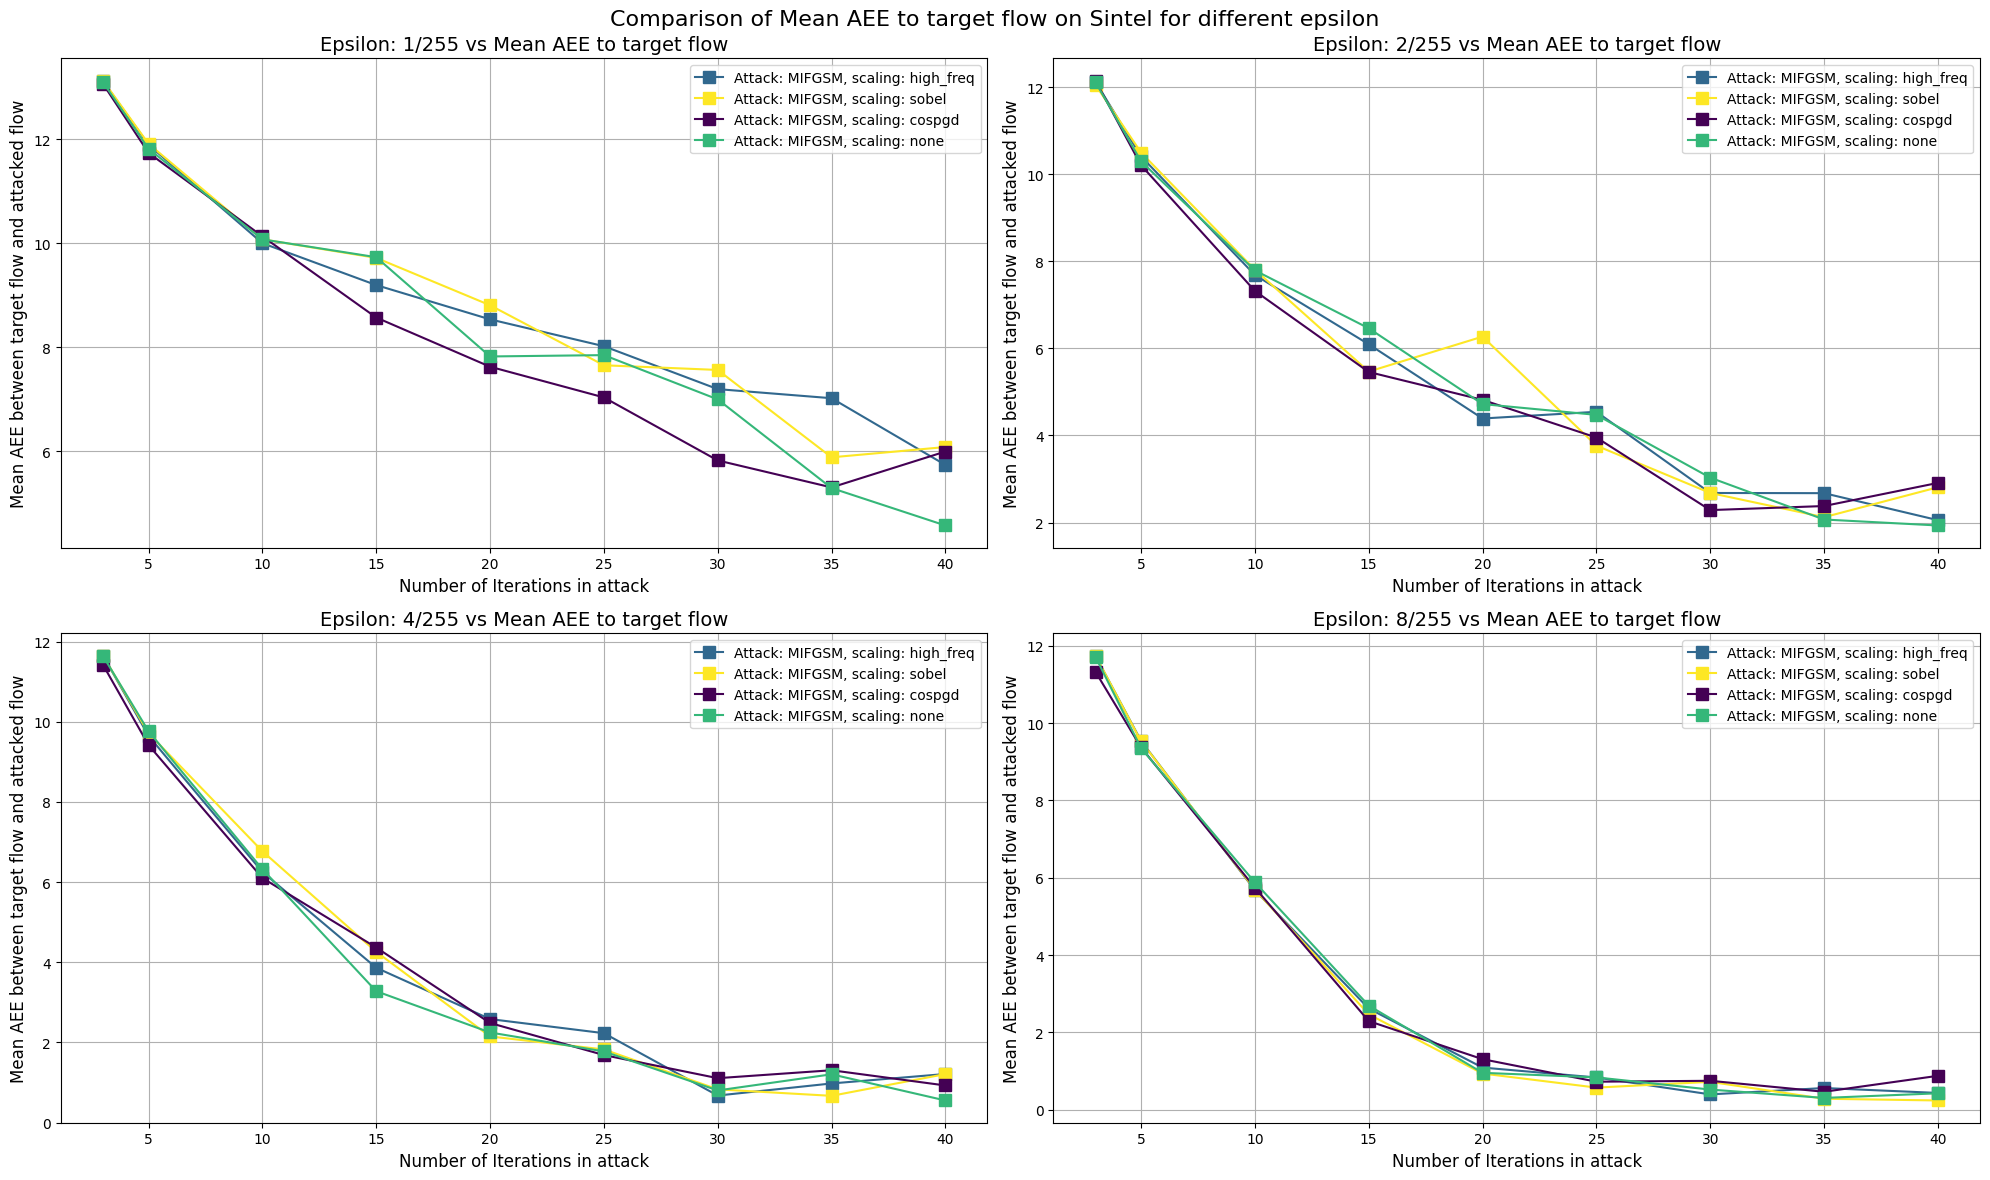

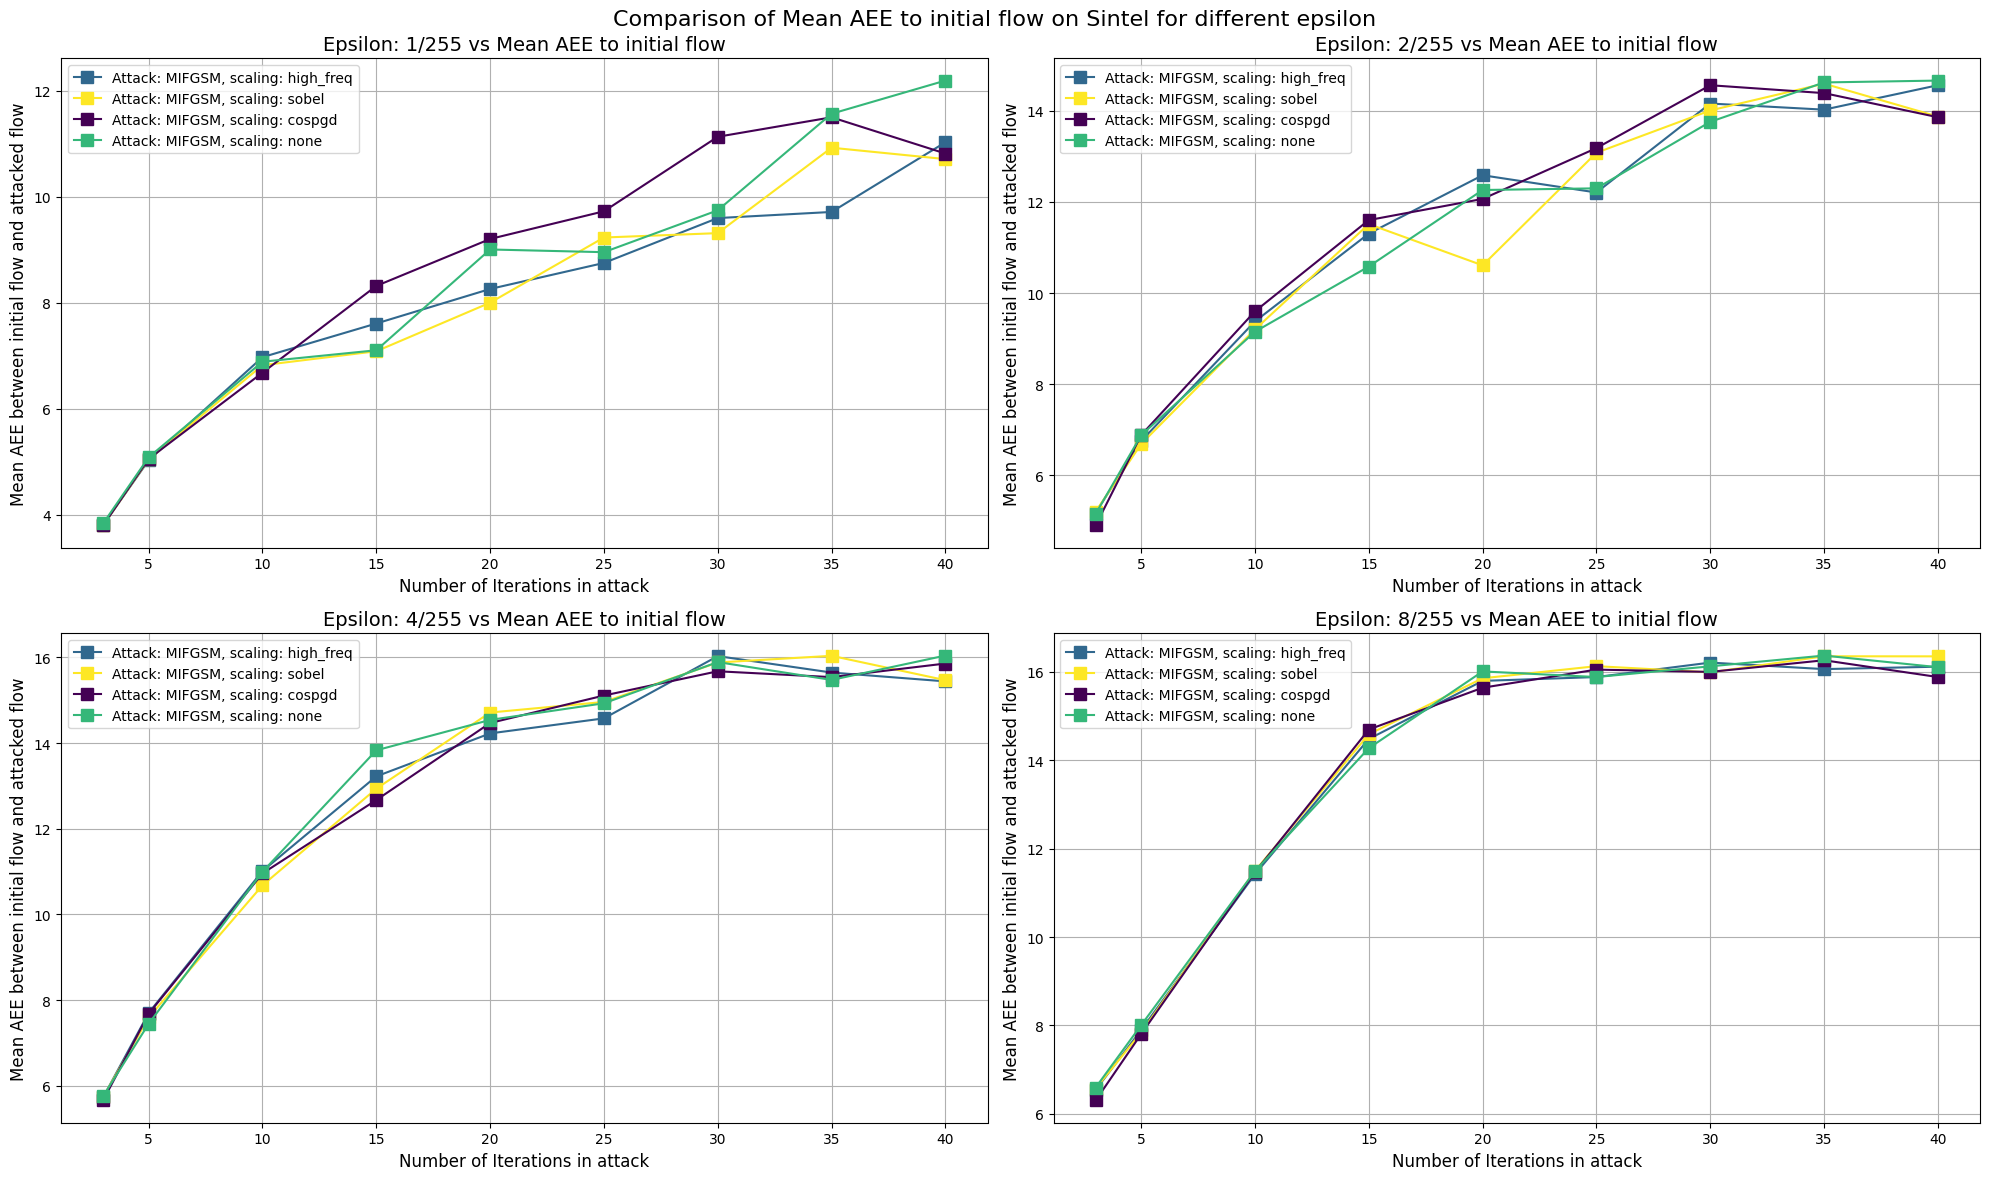

In [11]:
plot_alpha_vs_aee(runs)
plot_alpha_vs_aee(runs, 'mean_aee_init_attack_step_')

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np


def plot_alpha_vs_aee_with_runtime(runs_data, metric='mean_aee_target_attack_step_'):
    """
    Plots Mean AEE vs iterations in a 2×2 grid (one per epsilon),
    and shows each run’s actual duration (in seconds) in the legend.
    """
    # 1) sanity check & copy
    if not isinstance(runs_data, pd.DataFrame):
        raise ValueError("runs_data must be a pandas DataFrame")
    df = runs_data.copy()

    # 2) extract & compute durations (MLflow stores ms since epoch)
    if 'start_time' not in df.columns or 'end_time' not in df.columns:
        raise KeyError("runs_data must include 'start_time' & 'end_time'")
    df['start_ts'] = pd.to_datetime(df['start_time'], unit='ms')
    df['end_ts'] = pd.to_datetime(df['end_time'],   unit='ms')
    df['duration_s'] = (df['end_ts'] - df['start_ts']).dt.total_seconds()

    # 3) coerce your param columns
    df["params.alpha"] = df["params.alpha"].astype(float)
    df["params.no_softmax"] = df["params.no_softmax"].astype(str)
    df["params.use_map_scaling"] = df["params.use_map_scaling"].astype(bool)

    # 4) friendly metric label
    if "target" in metric:
        metric_label = "target flow"
    elif "init" in metric:
        metric_label = "initial flow"
    else:
        metric_label = metric.replace("_", " ")

    # 5) setup styling
    eps_groups = df.groupby("params.epsilon")
    eps_map = {0.00392: '1/255', 0.00784: '2/255',
               0.01568: '4/255', 0.03137: '8/255'}
    layers = sorted(df["params.attack_type"].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(layers)))
    color_map = dict(zip(layers, colors))
    marker_map = {True: 's', False: 'o'}

    # 6) build subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.flatten()
    fig.suptitle(
        f'Comparison of Mean AEE to {metric_label} on Kitti15\n'
        f'(legend shows actual runtime in seconds)',
        fontsize=16
    )

    for idx, (eps, group) in enumerate(eps_groups):
        ax = axes[idx]
        eps_frac = eps_map.get(float(eps), str(eps))
        ax.set_title(f"Epsilon: {eps_frac}", fontsize=14)
        ax.set_xlabel("Number of Iterations in attack", fontsize=12)
        ax.set_ylabel(f"Mean AEE to {metric_label}", fontsize=12)

        for _, row in group.iterrows():
            # styling
            layer = row["params.attack_type"]
            use_map = row["params.use_map_scaling"]
            color = color_map[layer]
            marker = marker_map[use_map]

            # pull out your AEE series
            aee = {}
            for col, val in row.items():
                if col.startswith('metrics.'+metric):
                    n = int(re.search(r'(\d+)$', col).group(1))
                    aee[n] = val
            steps = sorted(aee)
            vals = [aee[n] for n in steps]

            # get runtime
            dur = row['duration_s']

            # legend label now includes the actual runtime
            label = (f"{row['params.attack_type']}"
                     f" ({dur/32:.1f}s per image)")

            ax.plot(
                steps, vals,
                linestyle='-',
                marker=marker,
                color=color,
                markersize=8,
                label=label
            )

        ax.grid(True)
        ax.legend(fontsize=9)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

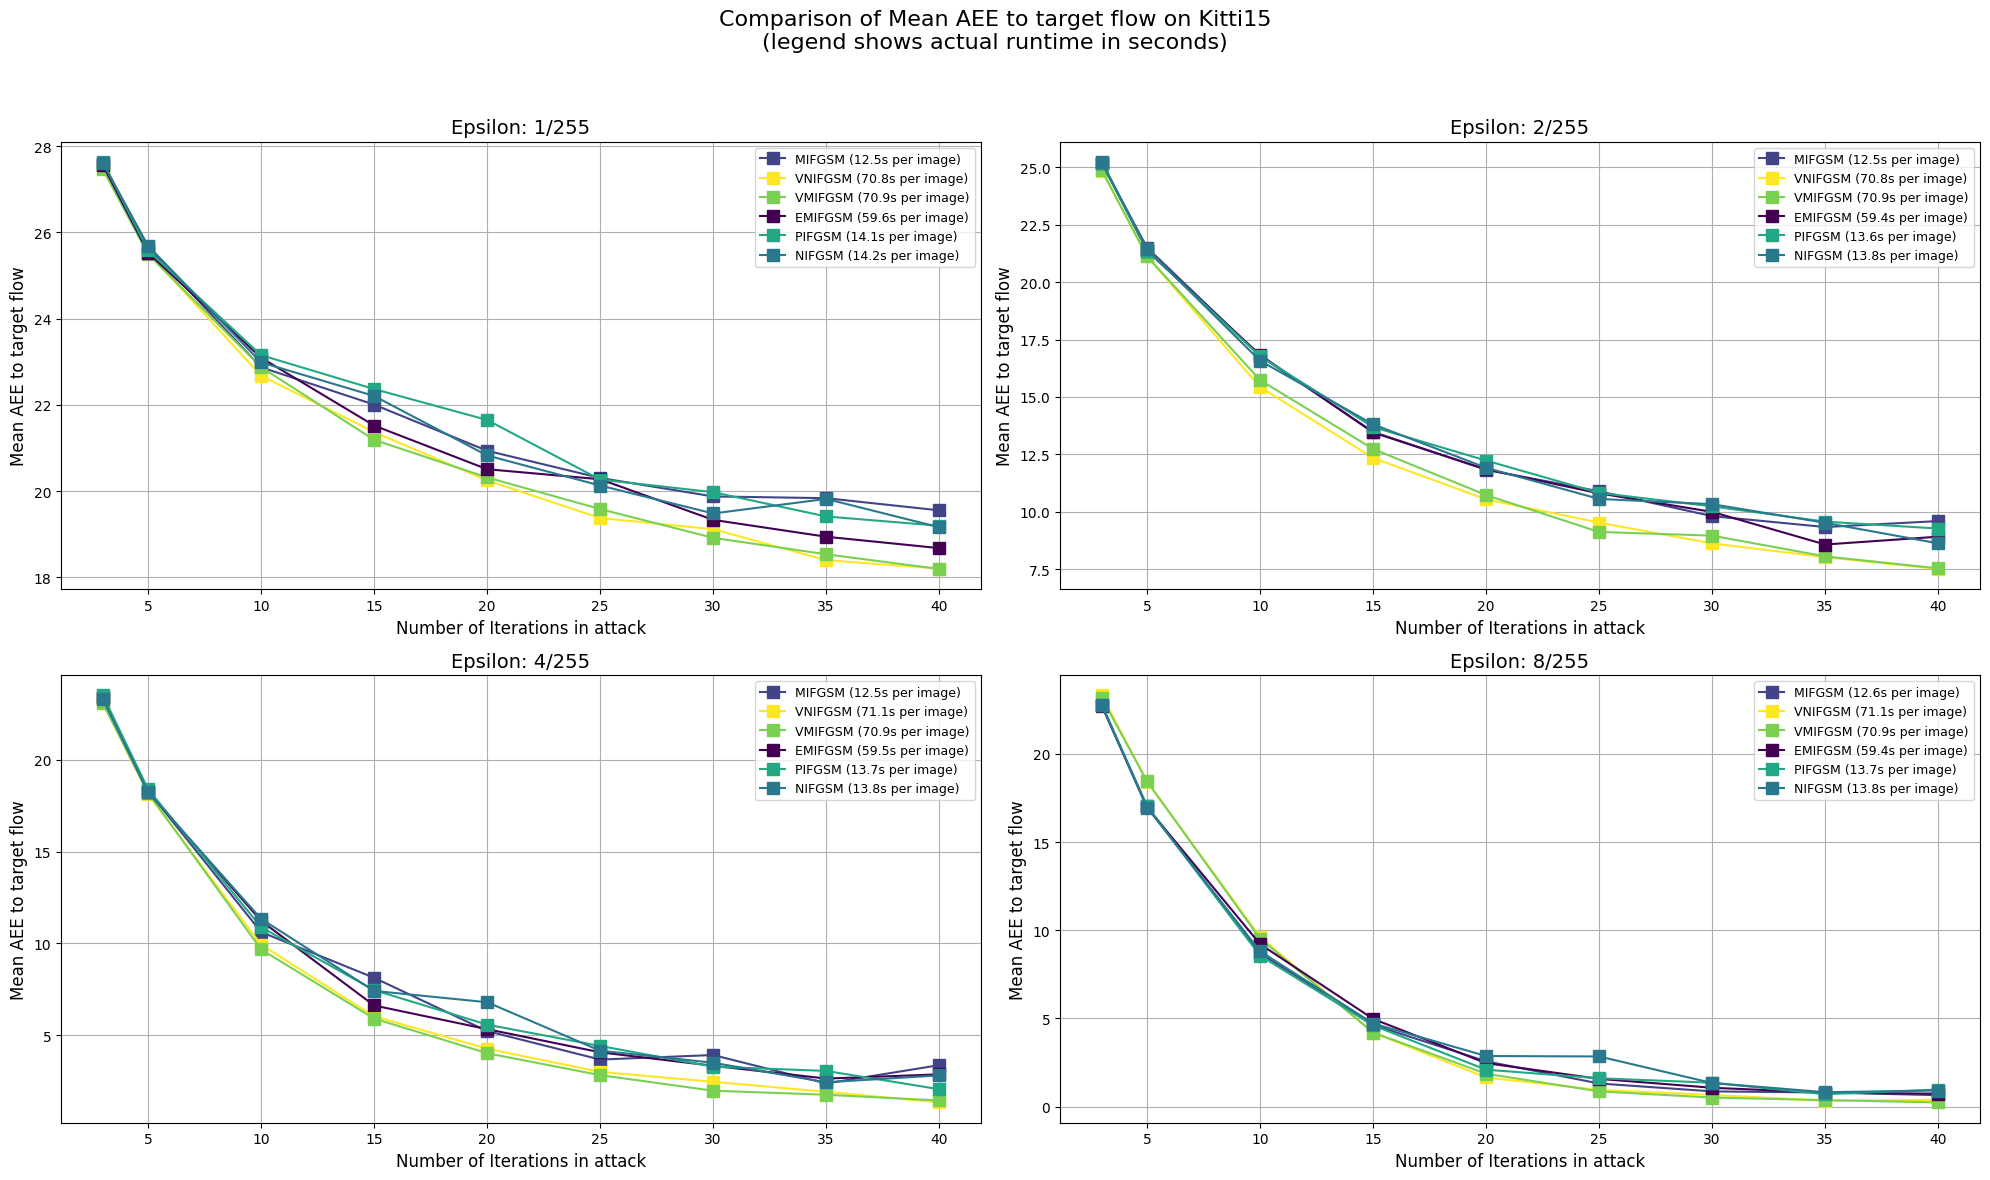

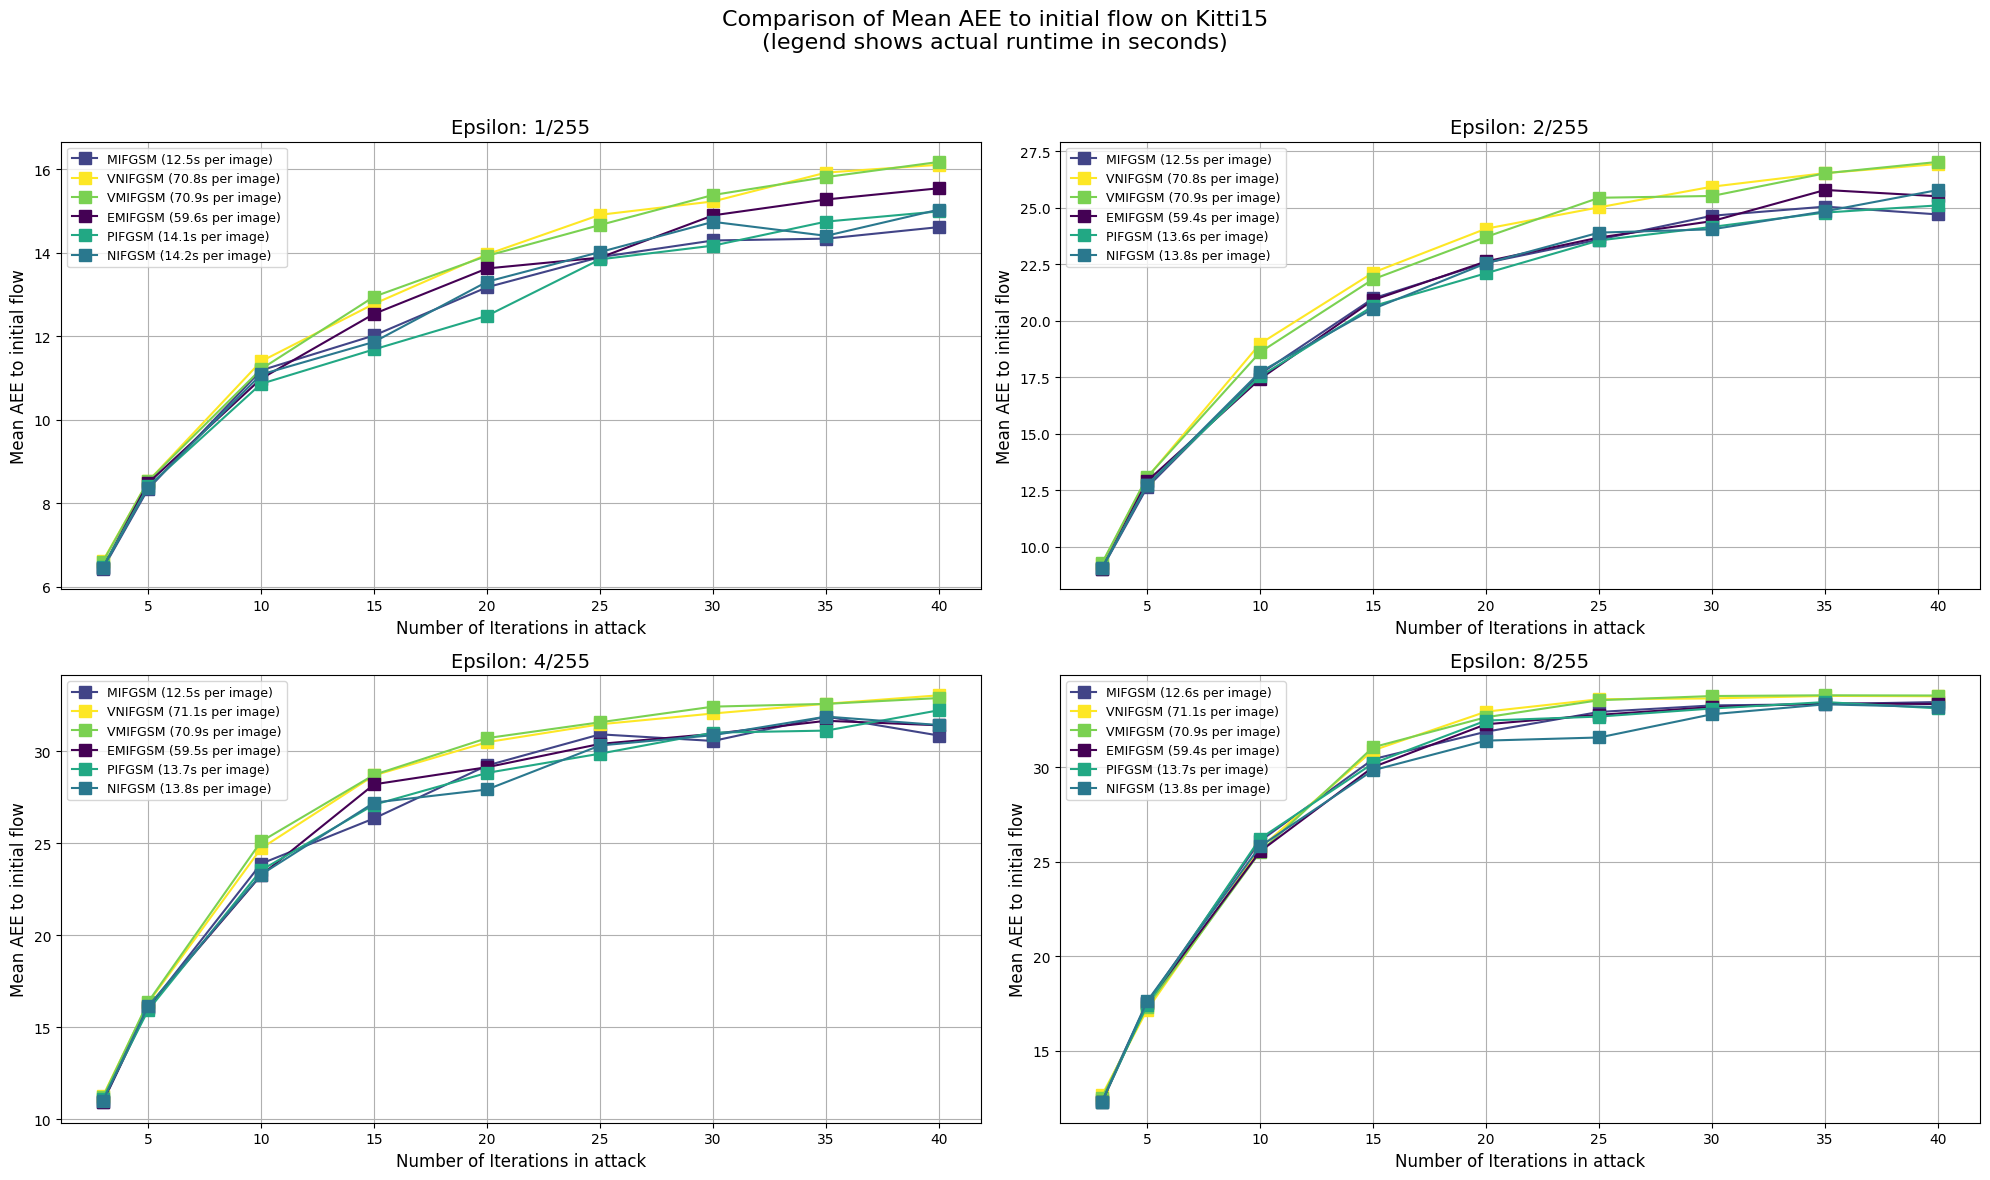

In [13]:
plot_alpha_vs_aee_with_runtime(runs)
plot_alpha_vs_aee_with_runtime(runs, 'mean_aee_init_attack_step_')

In [6]:
vmi_fgsm = ["020eac799464411bba155754c7ec3e5b","bf48ca33049f417f9756b69df17f0059","9cd06f43b8354bafa9960d7d0b8c11b2","be448f9d8c5a4cceab854c44d81f4da6","44d3b24178e1440eb50c29c5ae96493c","ccdb01c79d6246ec9751c6aedcdeccb7"]
ids_str = ", ".join(f"'{run}'" for run in vmi_fgsm)
# Формируем финальный запрос
filter_string = f"attributes.run_id IN ({ids_str})"
runs = mlflow.search_runs(
    experiment_ids=[experiment_id], filter_string=filter_string)

In [ ]:
plot_alpha_vs_aee(runs)
plot_alpha_vs_aee(runs, 'mean_aee_init_attack_step_')